# Решающие деревья: идея и реализация с нуля

В этом ноутбуке мы разберёмся, что такое **решающие деревья**, зачем они нужны и как устроены внутри.

**Цели ноутбука:**
- Понять идею дерева решений на простых примерах.
- Разобрать базовую терминологию (корень, узел, лист, глубина и т.д.).
- Научиться измерять качество разбиений (критерий Джини, энтропия и др.).
- Реализовать **простейшее дерево решений с нуля** на `numpy`.

Этот ноутбук упрощён, чтобы сделать идею максимально прозрачной. Позже мы посмотрим на более продвинутые модели (случайный лес и бустинг) в отдельных ноутбуках.

---

**Содержание:** Идея дерева → Критерии (Джини, энтропия) → Алгоритм CART → Реализация с нуля → Сравнение с sklearn.


## Идея решающего дерева

Решающее дерево последовательно задаёт вопросы о признаках объекта:

- **Вершина (узел)**: вопрос вида "`признак_j <= порог?`".
- **Левый/правый потомок**: куда мы идём в зависимости от ответа да/нет.
- **Лист**: финальное решение (класс или число).

Например, для задачи бинарной классификации можно представить дерево как серию простых проверок порогов: сначала по одному признаку, затем по другому и т.д. Каждое разбиение старается сделать подмножества более **однородными по целевому признаку**.


## Качество разбиения: критерий Джини и энтропия

Пусть у нас есть подвыборка с метками классов $y$. Обозначим через $p_k$ долю объектов класса $k$ в этой подвыборке.

**Критерий Джини**:

$$
Gini = 1 - \sum_k p_k^2.
$$

Он равен нулю, когда все объекты одного класса, и максимален при равномерном распределении классов.

**Энтропия**:

$$
H = - \sum_k p_k \log_2 p_k.
$$

Также измеряет неоднородность: чем больше смесь классов, тем выше энтропия.

При выборе разбиения дерево перебирает кандидатов (признак, порог) и выбирает тот, который **сильнее всего уменьшает** меру неоднородности (например, Джини).


## Формальное описание алгоритма дерева решений

Рассмотрим упрощённый вариант алгоритма построения дерева (семейство CART для классификации):

1. **На входе**: обучающая выборка $ (x_i, y_i)_{i=1}^N $.
2. В каждой вершине имеем подмножество объектов $S \subseteq \{1,\dots,N\}$.
3. Если выполняется критерий остановки (все объекты одного класса, достигнута максимальная глубина, слишком мало объектов и т.п.) — создаём **лист** с предсказанием (чаще всего, самым популярным классом в $S$).
4. Иначе перебираем кандидатов на разбиение:
   - выбираем признак $j$,
   - выбираем порог $t$,
   - делим множество $S$ на левое и правое подмножества:
     - $S_L = \{i \in S : x_{i,j} \le t\}$,
     - $S_R = \{i \in S : x_{i,j} > t\}$.
5. Для каждого кандидата считаем **критерий качества** (например, уменьшение индекса Джини):

$$
\Delta = Gini(S) - \frac{|S_L|}{|S|} Gini(S_L) - \frac{|S_R|}{|S|} Gini(S_R).
$$

6. Выбираем разбиение с максимальным $\Delta$ и рекурсивно строим левое и правое поддеревья.

Ключевая идея: каждое разбиение старается сделать подмножества как можно более **"чистыми"** по классам, жертвуя глобальной оптимальностью ради простой жадной стратегии.

### Гиперпараметры и переобучение

На практике важно ограничивать сложность дерева:
- **`max_depth`** — максимальная глубина дерева (число уровней разбиений). Без ограничения дерево легко переобучается.
- **`min_samples_split`** — минимальное число объектов в вершине, чтобы пробовать делить её дальше.
- **`min_samples_leaf`** — минимальное число объектов в листе.
- **`max_leaf_nodes`** — максимальное число листьев.

Большое, неглубоко ограниченное дерево может идеально запомнить обучающую выборку (нулевая ошибка на train), но обобщать хуже, чем более компактное дерево.

In [1]:
import numpy as np

np.random.seed(42)

n_samples = 200
n_features = 2

# Два простых кластера в 2D
X0 = np.random.normal(loc=[0.0, 0.0], scale=0.8, size=(n_samples // 2, n_features))
X1 = np.random.normal(loc=[2.0, 2.0], scale=0.8, size=(n_samples // 2, n_features))
X = np.vstack([X0, X1])
y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))

# Перемешаем выборку и сделаем простое train/test разбиение
perm = np.random.permutation(n_samples)
X = X[perm]
y = y[perm]

split = int(0.7 * n_samples)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train.shape, X_test.shape


((140, 2), (60, 2))

## Реализация простого дерева решений с нуля

Сделаем упрощённую реализацию бинарного дерева классификации:

- только бинарные разбиения вида `x[j] <= threshold`;
- критерий качества — индекс Джини;
- ограничение по глубине и минимальному размеру листа.

Это **обучающий пример**, чтобы увидеть, как дерево:
- перебирает сплиты;
- рекурсивно строит поддеревья;
- делает предсказание, спускаясь от корня к листу.


In [2]:
from collections import Counter

def gini_impurity(y: np.ndarray) -> float:
    """Индекс Джини для одномерного массива меток y."""
    if len(y) == 0:
        return 0.0
    classes, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1.0 - np.sum(p ** 2)


def best_split(X: np.ndarray, y: np.ndarray, min_samples_leaf: int = 1):
    """Поиск наилучшего разбиения по всем признакам и порогам.

    Возвращает (feature_index, threshold). Если разбиение не найдено, возвращает (None, None).
    """
    n_samples, n_features = X.shape
    if n_samples <= 1:
        return None, None

    parent_impurity = gini_impurity(y)
    best_gain = 0.0
    best_feature, best_threshold = None, None

    for feature in range(n_features):
        values = np.unique(X[:, feature])
        for threshold in values:
            left_mask = X[:, feature] <= threshold
            right_mask = ~left_mask

            if left_mask.sum() < min_samples_leaf or right_mask.sum() < min_samples_leaf:
                continue

            impurity_left = gini_impurity(y[left_mask])
            impurity_right = gini_impurity(y[right_mask])
            n_left, n_right = left_mask.sum(), right_mask.sum()
            impurity = (n_left * impurity_left + n_right * impurity_right) / n_samples
            gain = parent_impurity - impurity

            if gain > best_gain:
                best_gain = gain
                best_feature, best_threshold = feature, threshold

    return best_feature, best_threshold


class TreeNode:
    def __init__(self, *, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # значение в листе (класс)

    def is_leaf(self) -> bool:
        return self.value is not None


class DecisionTreeClassifierScratch:
    def __init__(self, max_depth: int | None = None, min_samples_split: int = 2, min_samples_leaf: int = 1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.tree_: TreeNode | None = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.n_classes_ = len(np.unique(y))
        self.n_features_ = X.shape[1]
        self.tree_ = self._grow_tree(X, y, depth=0)
        return self

    def _grow_tree(self, X: np.ndarray, y: np.ndarray, depth: int) -> TreeNode:
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        # Критерий остановки: все метки одинаковые, достигли макс. глубины или мало объектов
        if (
            num_labels == 1
            or num_samples < self.min_samples_split
            or (self.max_depth is not None and depth >= self.max_depth)
        ):
            leaf_value = self._most_common_label(y)
            return TreeNode(value=leaf_value)

        feature, threshold = best_split(X, y, min_samples_leaf=self.min_samples_leaf)
        if feature is None:
            leaf_value = self._most_common_label(y)
            return TreeNode(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_child = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._grow_tree(X[right_mask], y[right_mask], depth + 1)
        return TreeNode(feature=feature, threshold=threshold, left=left_child, right=right_child)

    @staticmethod
    def _most_common_label(y: np.ndarray):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    def _predict_one(self, x: np.ndarray) -> int:
        node = self.tree_
        assert node is not None
        while not node.is_leaf():
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self._predict_one(x) for x in X])


In [3]:
tree = DecisionTreeClassifierScratch(max_depth=3, min_samples_split=2, min_samples_leaf=1)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

train_acc = (y_pred_train == y_train).mean()
test_acc = (y_pred_test == y_test).mean()

print(f"Точность на train: {train_acc:.3f}")
print(f"Точность на test:  {test_acc:.3f}")


Точность на train: 0.979
Точность на test:  0.917


## Дерево решений в `sklearn`

Теперь посмотрим, как те же идеи реализованы в библиотеке `scikit-learn` через `DecisionTreeClassifier`.

Важно понимать, что:
- внутри `sklearn` используется высоко оптимизированная реализация алгоритма (на С/С++),
- но **концепция та же самая**: жадный выбор разбиений по критерию Джини или энтропии,
- гиперпараметры (`criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` и др.) напрямую связаны с идеями, которые мы обсудили выше.

Ниже сравним:
- качество нашего самописного дерева,
- качество `DecisionTreeClassifier` при разных настройках сложности.


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Базовое дерево из sklearn без жёстких ограничений
sk_tree = DecisionTreeClassifier(
    criterion="gini",      # можно указать "entropy" для информационного выигрыша
    max_depth=None,         # без ограничения глубины дерево переобучается
    random_state=42,
)
sk_tree.fit(X_train, y_train)

y_pred_train_sk = sk_tree.predict(X_train)
y_pred_test_sk = sk_tree.predict(X_test)

print("Полное дерево (max_depth=None):")
print(f"  train accuracy = {accuracy_score(y_train, y_pred_train_sk):.3f}")
print(f"  test  accuracy = {accuracy_score(y_test, y_pred_test_sk):.3f}")

# Более "регуляризованное" дерево с ограничением глубины
for depth in [1, 2, 3, 4, 5]:
    clf = DecisionTreeClassifier(criterion="gini", max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_tr = clf.predict(X_train)
    y_te = clf.predict(X_test)
    print(f"max_depth={depth}: train={accuracy_score(y_train, y_tr):.3f}, test={accuracy_score(y_test, y_te):.3f}")

# Сравнение с нашей самописной реализацией
print("\nСравнение с самописным деревом:")
print(f"  Наше дерево (max_depth=3)  : train={train_acc:.3f}, test={test_acc:.3f}")
print(f"  sklearn (max_depth=3)      : см. строку max_depth=3 выше")

Полное дерево (max_depth=None):
  train accuracy = 1.000
  test  accuracy = 0.933
max_depth=1: train=0.950, test=0.900
max_depth=2: train=0.971, test=0.917
max_depth=3: train=0.979, test=0.917
max_depth=4: train=0.986, test=0.933
max_depth=5: train=0.993, test=0.950

Сравнение с самописным деревом:
  Наше дерево (max_depth=3)  : train=0.979, test=0.917
  sklearn (max_depth=3)      : см. строку max_depth=3 выше


## Визуализация дерева из `sklearn`

Чтобы лучше понять, какие вопросы задаёт обученное дерево решений, удобно посмотреть на его структуру.

Используем функцию `sklearn.tree.plot_tree`:
- на осях будет само дерево с подписями вершин,
- в узлах увидим условие (например, `x[0] <= 0.5`),
- а также показатели: `gini`, число объектов `samples` и распределение классов `value`.

Для наглядности построим **умеренно глубокое** дерево (`max_depth=3`), чтобы визуализация поместилась на экране.

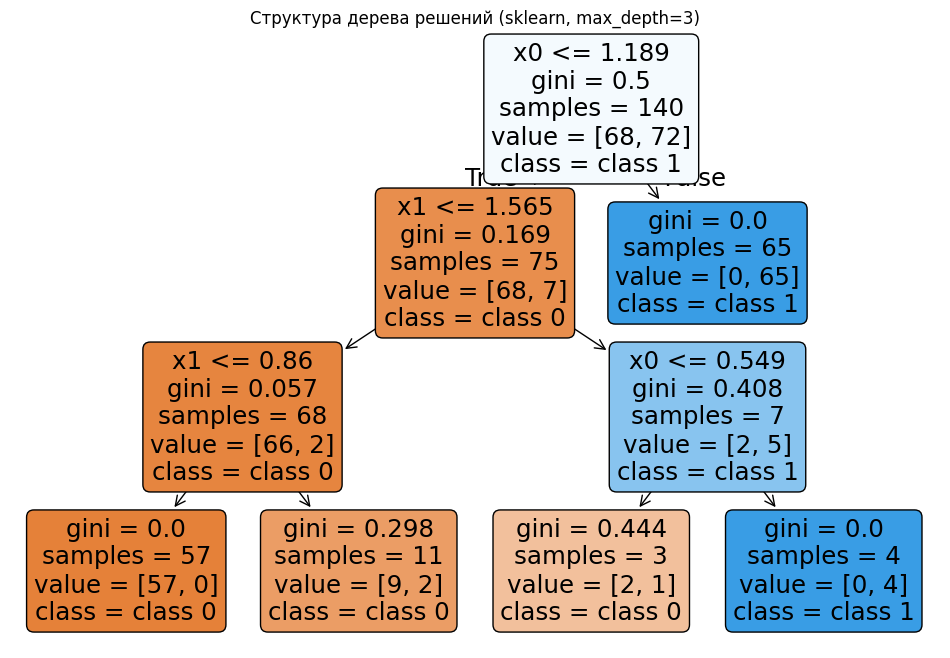

In [5]:
import matplotlib.pyplot as plt
from sklearn import tree as sktree

# Обучим компактное дерево для визуализации
vis_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42,
)
vis_tree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
sktree.plot_tree(
    vis_tree,
    filled=True,
    rounded=True,
    feature_names=[f"x{i}" for i in range(X_train.shape[1])],
    class_names=["class 0", "class 1"],
)
plt.title("Структура дерева решений (sklearn, max_depth=3)")
plt.show()

## Выводы

- Решающее дерево строит иерархию вопросов по признакам (пороги); качество разбиений измеряется критерием Джини или энтропией.
- Ограничение глубины и минимального числа объектов в листе необходимо для борьбы с переобучением.
- Реализация с нуля и сравнение с `DecisionTreeClassifier` из sklearn показывают единую логику CART-деревьев.